# Geo-Experiment Power Simulator — Pre-Analysis Guardrail Audit

**Goal:** Determine if a specific ad spend (expected % lift) can be detected amidst the historical noise of geographic sales data.

- Synthetic correlated Treatment vs Control (52 weeks, correlation > 0.80)
- Monte Carlo (100 iterations): random 6-week test window, inject true lift, estimate via time-based regression
- **Outputs:** Statistical power, power curve (1%–20% lift), Veto/Go decision, parallel trends check, counterfactual viz

In [9]:
# Geo-Experiment Power Simulator — Pre-Analysis Guardrail Audit
# Dependencies: numpy, pandas, matplotlib, seaborn, statsmodels
# %pip install numpy pandas matplotlib seaborn statsmodels

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

# --- 1. Generate synthetic historical sales (52 weeks, correlation > 0.80) ---
np.random.seed(42)
N_WEEKS = 52
# Common trend + shared noise to drive correlation
trend = np.linspace(100, 145, N_WEEKS)
shared_noise = np.random.normal(0, 4, N_WEEKS)
# Control: trend + shared noise + small idio noise
control = trend + shared_noise + np.random.normal(0, 2, N_WEEKS)
# Treatment: scale and shift of same base to keep correlation high
base = trend + shared_noise
treatment = 1.15 * base + np.random.normal(5, 2.5, N_WEEKS)
# Ensure no negatives (sales)
control = np.maximum(control, 20)
treatment = np.maximum(treatment, 20)
corr = np.corrcoef(control, treatment)[0, 1]
print(f"Control–Treatment correlation: {corr:.3f} (target > 0.80)")

df_wide = pd.DataFrame({"week": np.arange(1, N_WEEKS + 1), "control": control, "treatment": treatment})
# Long format for regression (market = 0 Control, 1 Treatment)
df_long = pd.concat([
    df_wide[["week", "control"]].rename(columns={"control": "sales"}).assign(market=0),
    df_wide[["week", "treatment"]].rename(columns={"treatment": "sales"}).assign(market=1),
], ignore_index=True)
df_long.head(10)

Control–Treatment correlation: 0.982 (target > 0.80)


,week,sales,market
0,1,100.633013,0
1,2,101.552648,0
2,3,106.417459,0
3,4,110.601738,0
4,5,100.914363,0
5,6,102.856792,0
6,7,112.273496,0
7,8,111.197300,0
8,9,104.222578,0
9,10,109.740099,0


## 2. Pre-period parallel trends check

We test whether Control and Treatment follow parallel trends in the **pre-period** (before any intervention). Regress `sales ~ week + market + week*market` on pre-period data; a non-significant `week*market` interaction supports parallel trends.

In [11]:
# Use first 40 weeks as "pre-period" for the parallel-trends check (no intervention yet)
pre_weeks = 40
df_pre = df_long[df_long["week"] <= pre_weeks].copy()
df_pre["week_x_market"] = df_pre["week"] * df_pre["market"]
X_pre = add_constant(df_pre[["week", "market", "week_x_market"]])
model_pre = OLS(np.log(df_pre["sales"]), X_pre).fit(
    cov_type="HC1"
)  # robust SEs
print("Parallel trends (pre-period): coefficient on week*market should be ~0")
print(model_pre.summary().tables[1])
pt_pval = model_pre.pvalues["week_x_market"]
print(f"\n>>> week*market p-value = {pt_pval:.4f} — parallel trends {'plausible' if pt_pval > 0.05 else 'questionable'}.")

Parallel trends (pre-period): coefficient on week*market should be ~0
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             4.6140      0.012    394.790      0.000       4.591       4.637
week              0.0068      0.000     14.533      0.000       0.006       0.008
market            0.1862      0.016     11.710      0.000       0.155       0.217
week_x_market    -0.0005      0.001     -0.740      0.460      -0.002       0.001

>>> week*market p-value = 0.4595 — parallel trends plausible.


In [12]:
# --- 3. Monte Carlo: one iteration = random 6-week window + inject lift + time-based regression ---
TEST_WEEKS = 6
N_ITERATIONS = 100


def run_one_iteration(df_long, lift_pct, test_start_week, seed=None):
    """
    Inject true lift into Treatment for weeks [test_start_week, test_start_week+TEST_WEEKS),
    fit log(sales) ~ week + market + post + market*post with cluster-robust SEs (by market).
    Returns: success (bool), estimated lift coef, p-value, and data for counterfactual plot.
    """
    if seed is not None:
        np.random.seed(seed)
    test_end = test_start_week + TEST_WEEKS
    df = df_long.copy()
    df["post"] = ((df["week"] >= test_start_week) & (df["week"] < test_end)).astype(int)
    df["market_x_post"] = df["market"] * df["post"]
    # Inject true effect: multiply Treatment sales in test window by (1 + lift_pct)
    mask_treat_post = (df["market"] == 1) & (df["post"] == 1)
    df.loc[mask_treat_post, "sales"] = df.loc[mask_treat_post, "sales"] * (1 + lift_pct)
    # Cluster ID for robust SEs (market = 0 or 1)
    cluster_id = df["market"].values
    X = add_constant(df[["week", "market", "post", "market_x_post"]])
    y = np.log(df["sales"])
    model = OLS(y, X).fit(cov_type="cluster", cov_kwds={"groups": cluster_id})
    coef_lift = model.params["market_x_post"]
    pval = model.pvalues["market_x_post"]
    success = (pval < 0.05) and (coef_lift > 0)
    # Counterfactual for treatment: predict with market_x_post = 0 (no intervention)
    X_cf = X.copy()
    X_cf["market_x_post"] = 0
    df["log_sales_fitted"] = model.predict(X)
    df["log_sales_counterfactual"] = model.predict(X_cf)
    df["sales_counterfactual"] = np.exp(df["log_sales_counterfactual"])
    return success, coef_lift, pval, model, df


def run_power_simulation(df_long, lift_pct, iterations=N_ITERATIONS, test_weeks=TEST_WEEKS):
    """Run Monte Carlo; return power and (optionally) last iteration for viz."""
    success_count = 0
    # Random test windows: start week in [1, 52 - test_weeks]
    max_start = N_WEEKS - test_weeks
    last_result = None
    for i in range(iterations):
        start_week = np.random.randint(1, max_start + 1)
        success, coef, pval, model, df_run = run_one_iteration(df_long, lift_pct, start_week)
        if success:
            success_count += 1
        last_result = (start_week, success, coef, pval, df_run)
    power = success_count / iterations
    return power, last_result


## 4. Single-iteration visualization: Actual vs Counterfactual

One run with a fixed test window to verify the model. **Actual** = treatment sales with injected lift; **Counterfactual** = predicted sales without intervention (market×post = 0).

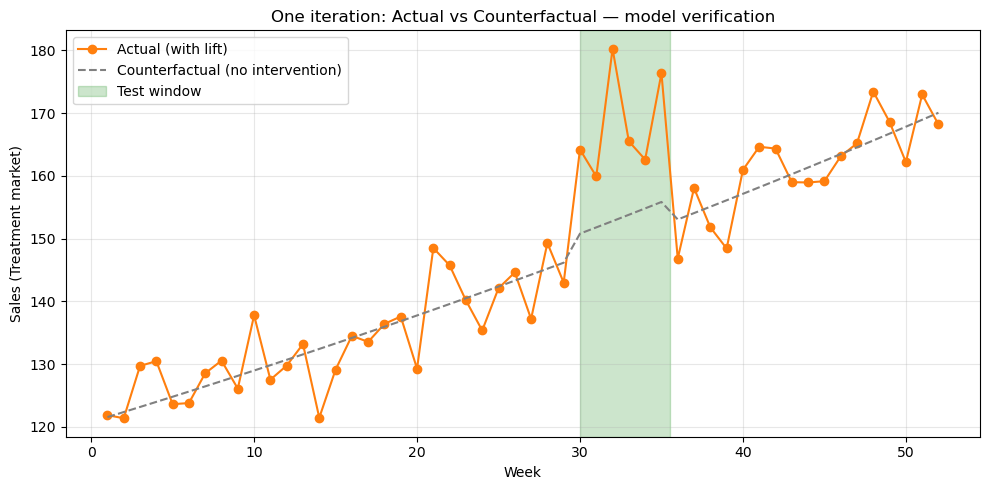

In [13]:
# --- 4. Single-iteration visualization: Actual vs Counterfactual (Treatment market) ---
# Fixed seed and test window for reproducible viz
VIZ_START_WEEK = 30
_, _, _, _, df_viz = run_one_iteration(
    df_long, lift_pct=0.10, test_start_week=VIZ_START_WEEK, seed=123
)
df_treat = df_viz[df_viz["market"] == 1].sort_values("week")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_treat["week"], df_treat["sales"], "o-", label="Actual (with lift)", color="C1")
ax.plot(
    df_treat["week"],
    df_treat["sales_counterfactual"],
    "--",
    label="Counterfactual (no intervention)",
    color="gray",
)
ax.axvspan(VIZ_START_WEEK, VIZ_START_WEEK + TEST_WEEKS - 0.5, alpha=0.2, color="green", label="Test window")
ax.set_xlabel("Week")
ax.set_ylabel("Sales (Treatment market)")
ax.set_title("One iteration: Actual vs Counterfactual — model verification")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Power curve (1%–20% lift) and Statistical Power

Run 100 iterations at each lift level; **Statistical Power** = proportion of iterations where we correctly detect a positive effect (p < 0.05 and estimated lift > 0).

Lift 1% -> Power = 93.00%
Lift 2% -> Power = 100.00%
Lift 3% -> Power = 100.00%
Lift 4% -> Power = 100.00%
Lift 5% -> Power = 100.00%
Lift 6% -> Power = 100.00%
Lift 7% -> Power = 100.00%
Lift 8% -> Power = 100.00%
Lift 9% -> Power = 100.00%
Lift 10% -> Power = 100.00%
Lift 11% -> Power = 100.00%
Lift 12% -> Power = 100.00%
Lift 13% -> Power = 100.00%
Lift 14% -> Power = 100.00%
Lift 15% -> Power = 100.00%
Lift 16% -> Power = 100.00%
Lift 17% -> Power = 100.00%
Lift 18% -> Power = 100.00%
Lift 19% -> Power = 100.00%
Lift 20% -> Power = 100.00%


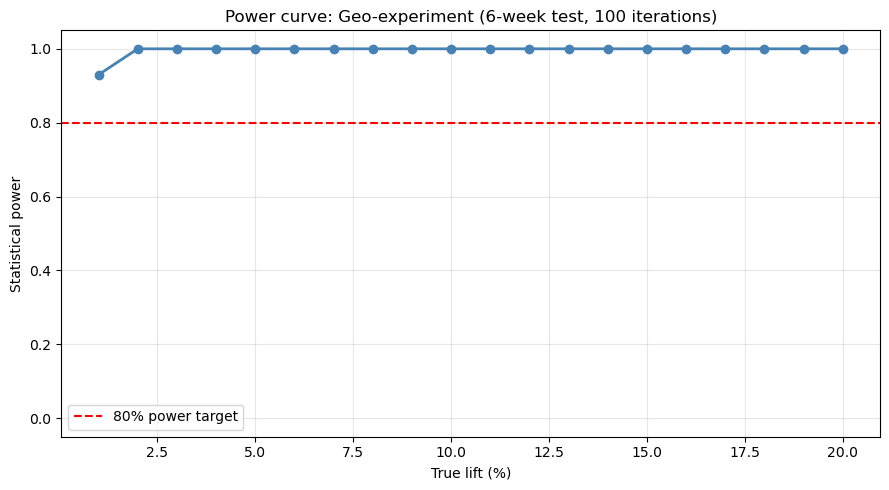

In [14]:
# Power curve: lift from 1% to 20%
lift_pcts = np.arange(1, 21) / 100.0
powers = []
for lift in lift_pcts:
    power, _ = run_power_simulation(df_long, lift_pct=lift, iterations=N_ITERATIONS)
    powers.append(power)
    print(f"Lift {lift*100:.0f}% -> Power = {power:.2%}")

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(lift_pcts * 100, powers, "o-", color="steelblue", linewidth=2)
ax.axhline(0.80, color="red", linestyle="--", label="80% power target")
ax.set_xlabel("True lift (%)")
ax.set_ylabel("Statistical power")
ax.set_title("Power curve: Geo-experiment (6-week test, 100 iterations)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

## 6. Veto / Go decision

If **Statistical Power < 80%** at the target lift (e.g. expected ad-spend lift), recommend **increasing test duration** or **increasing ad spend** (larger expected lift).

In [15]:
# Target lift from ad spend (e.g. 10% expected lift)
TARGET_LIFT_PCT = 0.10
POWER_TARGET = 0.80

# Get power at target lift (reuse powers/lift_pcts from above; ensure we have it)
idx_target = np.argmin(np.abs(np.array(lift_pcts) - TARGET_LIFT_PCT))
power_at_target = powers[idx_target]

print("=" * 60)
print("PRE-ANALYSIS GUARDRAIL AUDIT — VETO / GO")
print("=" * 60)
print(f"Target lift (expected from ad spend): {TARGET_LIFT_PCT*100:.0f}%")
print(f"Statistical power at target lift:    {power_at_target:.1%}")
print(f"Power target:                        {POWER_TARGET:.0%}")
if power_at_target >= POWER_TARGET:
    print("\n>>> GO: Power is sufficient. Proceed with experiment design.")
else:
    print("\n>>> VETO: Power is below 80%. Recommendation:")
    print("    • Increase test duration (e.g. longer test window), or")
    print("    • Increase ad spend to achieve a larger expected lift.")
print("=" * 60)

PRE-ANALYSIS GUARDRAIL AUDIT — VETO / GO
Target lift (expected from ad spend): 10%
Statistical power at target lift:    100.0%
Power target:                        80%

>>> GO: Power is sufficient. Proceed with experiment design.
